In [1]:
import pandas as pd

In [9]:
df = pd.read_csv('/media/zihengc/T7 Shield/mpra/MPRA_design/Get_sequences/Barcoding/2022.2.7 AD_MPRA_FINAL_INDELCORRECT/AD_MPRA_2_7/AD_MPRA_2_7_Contributor_20230213_unique_GeneName.csv',index_col=0)
df

,barcode_id,barcode_seq,enhancer_seq,enhancer_id,full_seq,ID,RSID,Contributor,nearest_gene
0,free16-1.1020750,GCAACCAACGCCTCCT,CCTCATTTTACAGAAGAGAGACCCATCAATCAACTGTGACTTCGCA...,alt:rs139359594:SNPCENTER:chr5:151082227:A:G:1...,GAGTCTGAACCTGTGTGCTACCTCATTTTACAGAAGAGAGACCCAT...,alt:rs139359594:SNPCENTER:chr5:151082227:A:G:1...,rs139359594,Hide,TNIP1
1,free16-1.843358,CTCCAGGTGTCAGCAT,CCTCATTTTACAGAAGAGAGACCCATCAATCAACTGTGACTTCGCA...,alt:rs139359594:SNPCENTER:chr5:151082227:A:G:1...,GAGTCTGAACCTGTGTGCTACCTCATTTTACAGAAGAGAGACCCAT...,alt:rs139359594:SNPCENTER:chr5:151082227:A:G:1...,rs139359594,Hide,TNIP1
2,free16-1.1182770,GGTTGGTAATGCTGGA,CCTCATTTTACAGAAGAGAGACCCATCAATCAACTGTGACTTCGCA...,alt:rs139359594:SNPCENTER:chr5:151082227:A:G:1...,GAGTCTGAACCTGTGTGCTACCTCATTTTACAGAAGAGAGACCCAT...,alt:rs139359594:SNPCENTER:chr5:151082227:A:G:1...,rs139359594,Hide,TNIP1
3,free16-1.931684,GAATCATAAGCCGAAT,CCTCATTTTACAGAAGAGAGACCCATCAATCAACTGTGACTTCGCA...,alt:rs139359594:SNPCENTER:chr5:151082227:A:G:1...,GAGTCTGAACCTGTGTGCTACCTCATTTTACAGAAGAGAGACCCAT...,alt:rs139359594:SNPCENTER:chr5:151082227:A:G:1...,rs139359594,Hide,TNIP1
4,free16-1.1395605,TCAGACGTTGTAATGT,CCTCATTTTACAGAAGAGAGACCCATCAATCAACTGTGACTTCGCA...,alt:rs139359594:SNPCENTER:chr5:151082227:A:G:1...,GAGTCTGAACCTGTGTGCTACCTCATTTTACAGAAGAGAGACCCAT...,alt:rs139359594:SNPCENTER:chr5:151082227:A:G:1...,rs139359594,Hide,TNIP1
...,...,...,...,...,...,...,...,...,...
23995,free16-1.208979,ACGGTTAGTGCTCGAC,GGTGTGGAAAGTCCCCAGGCTCCCCAGCAGGCAGAAGTATGCAAAG...,PanTissueControl.SV40_224bp_1xEnh_Promoter,GAGTCTGAACCTGTGTGCTAGGTGTGGAAAGTCCCCAGGCTCCCCA...,PanTissueControl.SV40_224bp_1xEnh_Promoter:fre...,SV40,Pfenning,NaN
23996,free16-1.1404458,TCATCTTATTGTCACC,GGTGTGGAAAGTCCCCAGGCTCCCCAGCAGGCAGAAGTATGCAAAG...,PanTissueControl.SV40_224bp_1xEnh_Promoter,GAGTCTGAACCTGTGTGCTAGGTGTGGAAAGTCCCCAGGCTCCCCA...,PanTissueControl.SV40_224bp_1xEnh_Promoter:fre...,SV40,Pfenning,NaN
23997,free16-1.1303027,TAATAGGTGCTGTCCA,GGTGTGGAAAGTCCCCAGGCTCCCCAGCAGGCAGAAGTATGCAAAG...,PanTissueControl.SV40_224bp_1xEnh_Promoter,GAGTCTGAACCTGTGTGCTAGGTGTGGAAAGTCCCCAGGCTCCCCA...,PanTissueControl.SV40_224bp_1xEnh_Promoter:fre...,SV40,Pfenning,NaN
23998,free16-1.1373862,TATGCCTGGATGGAGC,GGTGTGGAAAGTCCCCAGGCTCCCCAGCAGGCAGAAGTATGCAAAG...,PanTissueControl.SV40_224bp_1xEnh_Promoter,GAGTCTGAACCTGTGTGCTAGGTGTGGAAAGTCCCCAGGCTCCCCA...,PanTissueControl.SV40_224bp_1xEnh_Promoter:fre...,SV40,Pfenning,NaN


In [23]:
allele = pd.read_csv("/media/zihengc/T7 Shield/mpra3_lib_analysis/Allele_effects_barcodes/32barcodes/Allele_effects_no_interaction/20230416_comparative_HMC3_Allele_nointeraction.csv",index_col=0)

allele_sig = allele[allele["fdr"]<=0.05]
motif_disrupt = allele_sig.index[~allele_sig.index.str.startswith(('ref', 'alt'))]

index = pd.read_csv('/media/zihengc/T7 Shield/mpra3_lib_analysis/indexing/ALT_REF_LookUpTable_20220214.csv' ,header=None,index_col=0)
motif_disrupt_ref = index.loc[motif_disrupt][1].tolist()

In [26]:

df_tmp = df[df["enhancer_id"].isin(motif_disrupt_ref)].drop_duplicates("enhancer_seq")
# create a new file to write the fasta data to
with open('/media/zihengc/T7 Shield/mpra3_lib_analysis/Allele_effects_barcodes/32barcodes/motif_disrupt_significant_HMC3_227bp_ref.fasta', 'w') as f:
    # iterate over the rows of the dataframe
    for index, row in df_tmp.iterrows():
        # write the header line
        f.write('>' + row['ID'] + '\n')
        # write the sequence in 60-character lines
        seq = row['enhancer_seq']
        for i in range(0, len(seq), 60):
            f.write(seq[i:i+60] + '\n')

In [27]:

df_tmp = df[df["enhancer_id"].isin(motif_disrupt)].drop_duplicates("enhancer_seq")
# create a new file to write the fasta data to
with open('/media/zihengc/T7 Shield/mpra3_lib_analysis/Allele_effects_barcodes/32barcodes/motif_disrupt_significant_HMC3_227bp_alt.fasta', 'w') as f:
    # iterate over the rows of the dataframe
    for index, row in df_tmp.iterrows():
        # write the header line
        f.write('>' + row['ID'] + '\n')
        # write the sequence in 60-character lines
        seq = row['enhancer_seq']
        for i in range(0, len(seq), 60):
            f.write(seq[i:i+60] + '\n')

In [19]:
left = "ACAAGggaagccccaagaaaaagcggaaggtgtaaGTCTCGTGGGCTCGGAGATGTGTATAAGAGACAGggatccACggcGCGCCAAATGGAGAAACATG".upper()
right = "TGGTACCTAGCATCTCACCCCTGTCTCTTATACACATCTGACGCTGCCGACGATCTAATTTAATATATTGATATTTATATCATTTTACGTTTCTCGTTCA".upper()
df["full_seq_500bp"]=left+df["full_seq"]+right

In [20]:

# create a new file to write the fasta data to
with open('/media/zihengc/T7 Shield/mpra/MPRA_design/Get_sequences/Barcoding/2022.2.7 AD_MPRA_FINAL_INDELCORRECT/AD_MPRA_2_7/500bp_MPRA_full_seq.fasta', 'w') as f:
    # iterate over the rows of the dataframe
    for index, row in df.iterrows():
        # write the header line
        f.write('>' + row['ID'] + '\n')
        # write the sequence in 60-character lines
        seq = row['full_seq_500bp']
        for i in range(0, len(seq), 60):
            f.write(seq[i:i+60] + '\n')

In [72]:
merged_unique_motifs = pd.read_csv('/media/zihengc/T7 Shield/mpra/MPRA_design/Motif_search/unique_motifs.csv',index_col=0)
merged_unique_motifs
merged_unique_motifs.set_index("rsID").loc[df_tmp["RSID"].unique()]

,index,Motifs,motifs_clean,STAT,Mef2,NF-kappaB,PU.1,Irf,AP-1,Foxo
rsID,,,,,,,,,,
rs188776976,1847,Brachyury_1;Evi-1_4;Irf_known10;Irf_known11;Ir...,"['Brachyury', 'Evi-1', 'Irf', 'Irf', 'Irf', 'I...",1,1,0,0,1,0,0
rs113046258,53,AP-1_disc3;AP-1_known3;AP-1_known4;AP-2_disc1;...,"['AP-1', 'AP-1', 'AP-1', 'AP-2', 'BAF155', 'BA...",1,1,0,0,1,1,0
rs6733839,1680,Dobox4;Mef2_known1;Mef2_known4;Mef2_known6;NF-...,"['Dobox4', 'Mef2', 'Mef2', 'Mef2', 'NF-kappaB'...",0,1,1,0,0,0,0
rs12703526,1683,STAT_known1,['STAT'],1,0,0,0,0,0,0
rs113762153,1987,CTCF_disc7;NF-kappaB_known1;TCF11::MafG;Zfp161_1,"['CTCF', 'NF-kappaB', 'TCF11::MafG', 'Zfp161']",0,0,1,0,0,0,0
rs73972710,20,AP-2_known1;AP-2_known7;BDP1_disc1;EBF_disc2;E...,"['AP-2', 'AP-2', 'BDP1', 'EBF', 'Egr-1', 'Myc'...",0,0,1,0,0,0,0
rs3783763,181,CEBPG;HDAC2_disc6;HMG-IY_2;Hoxa9;Hoxb13;Hoxd10...,"['CEBPG', 'HDAC2', 'HMG-IY', 'Hoxa9', 'Hoxb13'...",0,0,0,0,1,0,0
rs73762103,256,AP-1_known1;Bach2;ERalpha-a_disc4;HNF4_disc1;H...,"['AP-1', 'Bach2', 'ERalpha-a', 'HNF4', 'HNF4',...",0,0,0,0,0,1,0
rs3783765,341,Bbx;Cdx;Foxa_known1;Foxj1_1;Foxj2_1;Foxk1;Foxl...,"['Bbx', 'Cdx', 'Foxa', 'Foxj1', 'Foxj2', 'Foxk...",0,0,0,0,0,0,1


In [54]:
sig_rsid_motifs = merged_unique_motifs.set_index("rsID").loc[df_tmp["RSID"].unique()].motifs_clean.tolist()

import ast
motif_words = []
for i in range(len(sig_rsid_motifs)):
    motif_words = motif_words+ list(set(ast.literal_eval(sig_rsid_motifs[i])))
#remove "-"
motif_words = [x.replace('-', '') for x in motif_words]

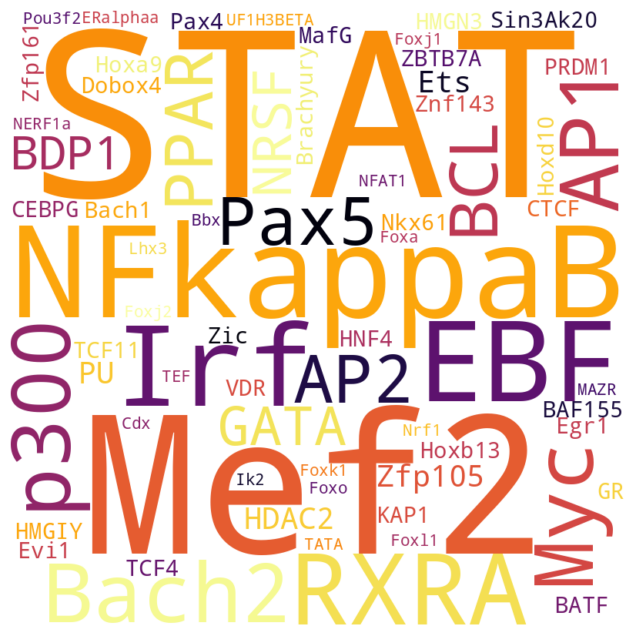

In [71]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Create a list of words

# Convert the list of words to a string with each word separated by a space
text = ' '.join(motif_words)

# Create a WordCloud object
wordcloud = WordCloud(width=800, height=800, background_color='white', colormap='inferno').generate(text)

# Display the WordCloud image
plt.figure(figsize=(8,8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()
